# Neuron sim

In [1]:
from neuron import h
import neuron
import numpy as np
import pandas as pd
from scipy import stats as st
from scipy import signal as ss

import matplotlib.pyplot as plt
import os

In [2]:

###################### Load and organize Excel file ################################
circuit_params = {}

#Import Excel file
circuit_params = pd.read_excel('Circuit_param.xls', sheet_name = None, index_col = 0)

#Get cell names and import biophys
cell_names = [i for i in circuit_params['conn_probs'].axes[0]]

#  **``LFPy``** rand **``NetPyNE``**

In [3]:
circuit_params['SING_CELL_PARAM']

,HL23PYR,HL23SST,HL23PV,HL23VIP
GOU,0.000028,0.000030,0.000280,0.000066
norm_tonic,0.000938,0.000938,0.000938,0.000938
drug_tonic,0.001352,0.001030,0.001091,0.000938
apic_tonic,0.000938,0.000938,0.000938,0.000938
drug_apic_tonic,0.001352,0.001030,0.001091,0.000938
cell_num,2.000000,2.000000,2.000000,2.000000
rotate_x,3.000000,1.770000,6.000000,-1.570000
rotate_y,4.000000,2.770000,7.000000,3.570000


In [4]:
SPIKES = np.load("Circuit_output/SPIKES_Seed1234.npy", allow_pickle=True)

In [5]:
VOLTAGES = np.load("Circuit_output/VOLTAGES_Seed1234.npy", allow_pickle=True)

In [6]:
import pickle as pkl

with open("Circuit_output/v1_batch1_data.pkl", "rb") as f:
    data = pkl.load(f)

print("Loaded data type:", type(data))
if hasattr(data, "keys"):
    print("Keys:", list(data.keys()))
else:
    print("Data len:", len(data))

Loaded data type: <class 'dict'>
Keys: ['netpyne_version', 'netpyne_changeset', 'net', 'simConfig', 'simData']


In [7]:
data['simData']['V_soma'].keys()

dict_keys(['cell_0', 'cell_1', 'cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6', 'cell_7'])

In [8]:
# use existing data (plt already imported)
voltage_data = VOLTAGES.item()['volts']  # list-of-lists by population/cell
pop_names = cell_names  # ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']

# time axis by sample index (if no explicit dt available)
n_samples = len(voltage_data[0][0])
t = np.arange(0, 10000, 10000/n_samples)

cells = ["cell_"+str(i) for i in range(0,8)]
# fig = plt.figure(figsize=(24, 12))
# ii = 0
# for i in range(4):
#     for j in range(10):
#         plt.subplot(4,10, ii+1)
#         plt.plot(t[: len(np.asarray(voltage_data[0][0]))], np.asarray(voltage_data[i][j]), label="LFPy", color='blue')
#         plt.plot(data['simData']['t'], data['simData']['V_soma'][cells[ii]], label="NetPYNE", color='k', alpha = 0.5, linewidth=3)
#         ii = ii + 1
#         plt.ylabel('V (mV)')
#         plt.xlim(0, 200.0)
#         # plt.xlim(42, 46.0)
#         # plt.ylim(-84, -70)
#         plt.legend()
#         plt.grid(True)
#         if i == 3:
#             plt.xlabel('time (ms)')
#         # if i == 0:
#         #     plt.ylim(-75, -70)
# plt.show()



 	 POP: 0
mean PSPs: Exc-Exc -> LFPy: 4.673020 mV (1078) 	 	 NetPyNE: 4.634102 mV (1090)
mean PSPs: Exc-Exc -> LFPy: 0.767996 mV (11) 	 	 NetPyNE: 0.767970 mV (11)


 [ 4.98794539e-06 -6.52024512e-06 -5.73636976e-06 -2.16927731e-07
 -2.33926983e-07 -2.16929067e-07 -2.82378352e-07 -2.16885581e-07
 -2.90661653e-04  1.67866148e-07  4.66175837e-06] 






 	 POP: 1
mean PSPs: Exc-INH -> LFPy: 2.226883 mV (8) 	 	 NetPyNE: 2.227015 mV (8)


 [ 0.00026777  0.00027948  0.00026378  0.00026372  0.00026376  0.00028264
  0.00026374 -0.00082871] 




mean PSPs: Exc-INH -> LFPy: 2.038567 mV (7) 	 	 NetPyNE: 2.038835 mV (7)


 [0.00026812 0.00026413 0.00026406 0.00026411 0.00026398 0.00026412
 0.00029415] 






 	 POP: 2
mean PSPs: Exc-INH -> LFPy: 4.103877 mV (12) 	 	 NetPyNE: 4.103628 mV (12)


 [ 9.04566340e-05  7.90728780e-05  8.95195984e-05  8.66348836e-05
  8.77037108e-05 -2.33549851e-03  8.93955802e-05  8.93356386e-05
  8.77043282e-05 -1.56277102e-03  9.23612278e-05  1.19713213e-04] 




me

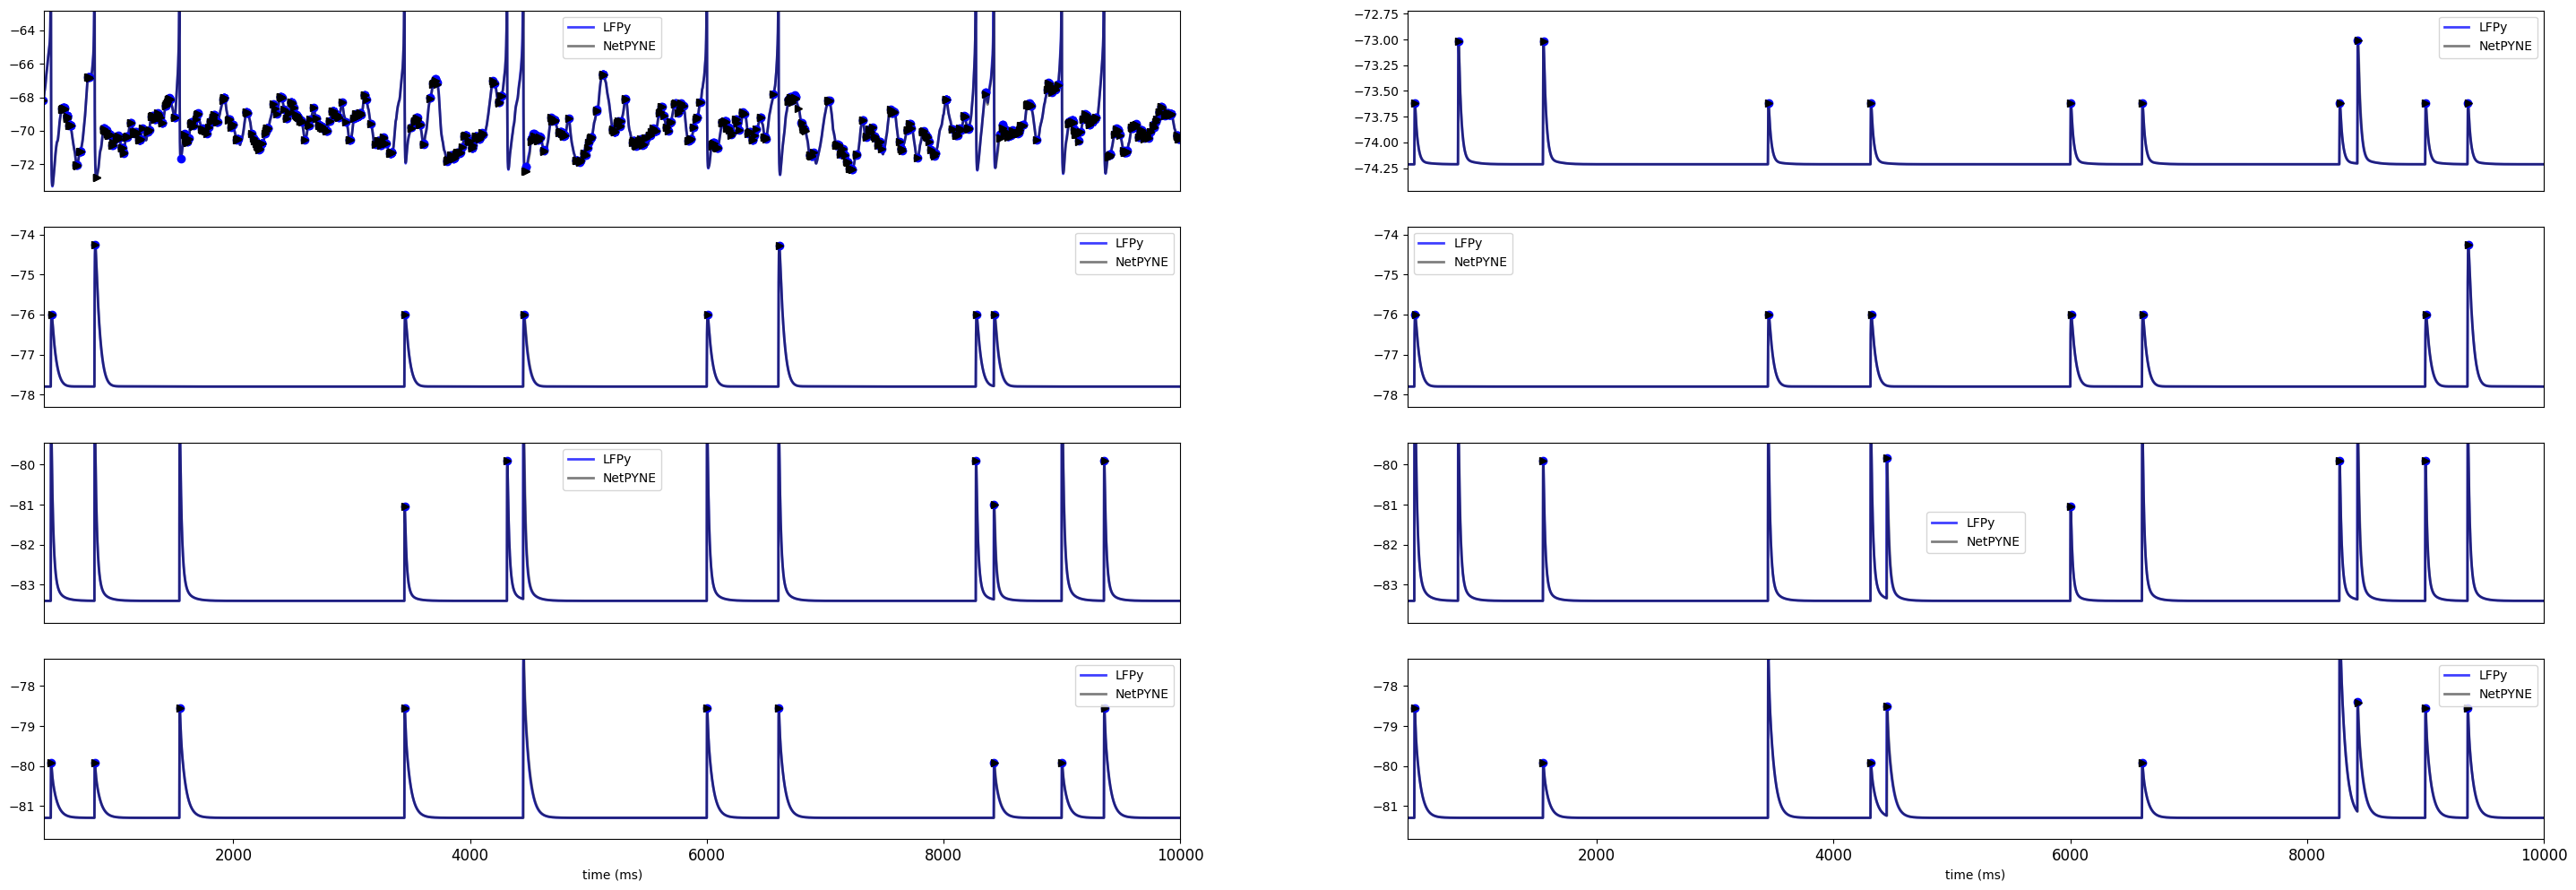

In [33]:
fig = plt.figure(figsize=(36, 12))

N = {}
L = {}
for i in range(4):
    N[i] = []
    L[i] = []

ii = 0
for i in range(4):
    print("\n\n \t POP:", i)
    for j in range(2):
        plt.subplot(4,2, ii+1)
        trace1 = np.asarray(voltage_data[i][j])[4000:10*40000]
        trace2 = data['simData']['V_soma'][cells[ii]][4000:10*40000]
        minV1 = np.min(list(trace1)+list(trace2))
        meanV1 = np.mean(list(trace1)+list(trace2))

        NetPyNEidx, NetPyNEpeak = ss.find_peaks(trace2, height=minV1+0.1)
        LFPyidx, LFPypeak = ss.find_peaks(trace1, height=minV1+0.1)
        
        plt.plot(t[: len(np.asarray(voltage_data[0][0]))], np.asarray(voltage_data[i][j]), label="LFPy", alpha = 0.75, linewidth=2, color='blue')
        plt.plot(data['simData']['t'], data['simData']['V_soma'][cells[ii]], label="NetPYNE", color='k', alpha = 0.5, linewidth=2)
        plt.plot(0.025*LFPyidx+100, LFPypeak['peak_heights'], 'o', color='blue')
        plt.plot(0.025*NetPyNEidx+100, NetPyNEpeak['peak_heights'], '>', color='k')
        if i == 0:
            if j ==1:            
                plt.ylim(minV1-0.25, minV1+1.5)
            else:            
                plt.ylim(minV1-0.25, minV1+10.5)
            print("mean PSPs: Exc-Exc -> LFPy: %.6f mV (%d) \t \t NetPyNE: %.6f mV (%d)" % (LFPypeak['peak_heights'].mean()-minV1, len(LFPypeak['peak_heights']), NetPyNEpeak['peak_heights'].mean()-minV1,len(NetPyNEpeak['peak_heights'])))
        else:
            print("mean PSPs: Exc-INH -> LFPy: %.6f mV (%d) \t \t NetPyNE: %.6f mV (%d)" % (LFPypeak['peak_heights'].mean()-minV1, len(LFPypeak['peak_heights']), NetPyNEpeak['peak_heights'].mean()-minV1,len(NetPyNEpeak['peak_heights'])))
        if i > 0:
            plt.ylim(minV1-0.5, minV1+4.0)

        plt.xlim(400, 10000.0)
        plt.legend()

        if i == 3:
            plt.xticks(fontsize=12)
            plt.xlabel("time (ms)")
        else:
            plt.xticks([],fontsize=12)
            plt.xlabel("")
        
        L[i] = L[i] + list(LFPypeak['peak_heights']-minV1)
        N[i] = N[i] + list(NetPyNEpeak['peak_heights']-minV1)
        ii = ii + 1
        if ii > 1:
            print("\n\n",NetPyNEpeak['peak_heights'] - LFPypeak['peak_heights'], "\n\n\n\n")




 	 POP: 0
mean PSPs: Exc-Exc -> LFPy: 4.673020 mV (1078) 	 	 NetPyNE: 4.634102 mV (1090)
mean PSPs: Exc-Exc -> LFPy: 0.767996 mV (11) 	 	 NetPyNE: 0.767970 mV (11)


 [ 4.98794539e-06 -6.52024512e-06 -5.73636976e-06 -2.16927731e-07
 -2.33926983e-07 -2.16929067e-07 -2.82378352e-07 -2.16885581e-07
 -2.90661653e-04  1.67866148e-07  4.66175837e-06] 






 	 POP: 1
mean PSPs: Exc-INH -> LFPy: 2.226883 mV (8) 	 	 NetPyNE: 2.227015 mV (8)
mean PSPs: Exc-INH -> LFPy: 2.038567 mV (7) 	 	 NetPyNE: 2.038835 mV (7)


 	 POP: 2
mean PSPs: Exc-INH -> LFPy: 4.103877 mV (12) 	 	 NetPyNE: 4.103628 mV (12)
mean PSPs: Exc-INH -> LFPy: 4.289585 mV (12) 	 	 NetPyNE: 4.289268 mV (12)


 	 POP: 3
mean PSPs: Exc-INH -> LFPy: 2.353201 mV (10) 	 	 NetPyNE: 2.353210 mV (10)
mean PSPs: Exc-INH -> LFPy: 2.770078 mV (10) 	 	 NetPyNE: 2.768777 mV (10)


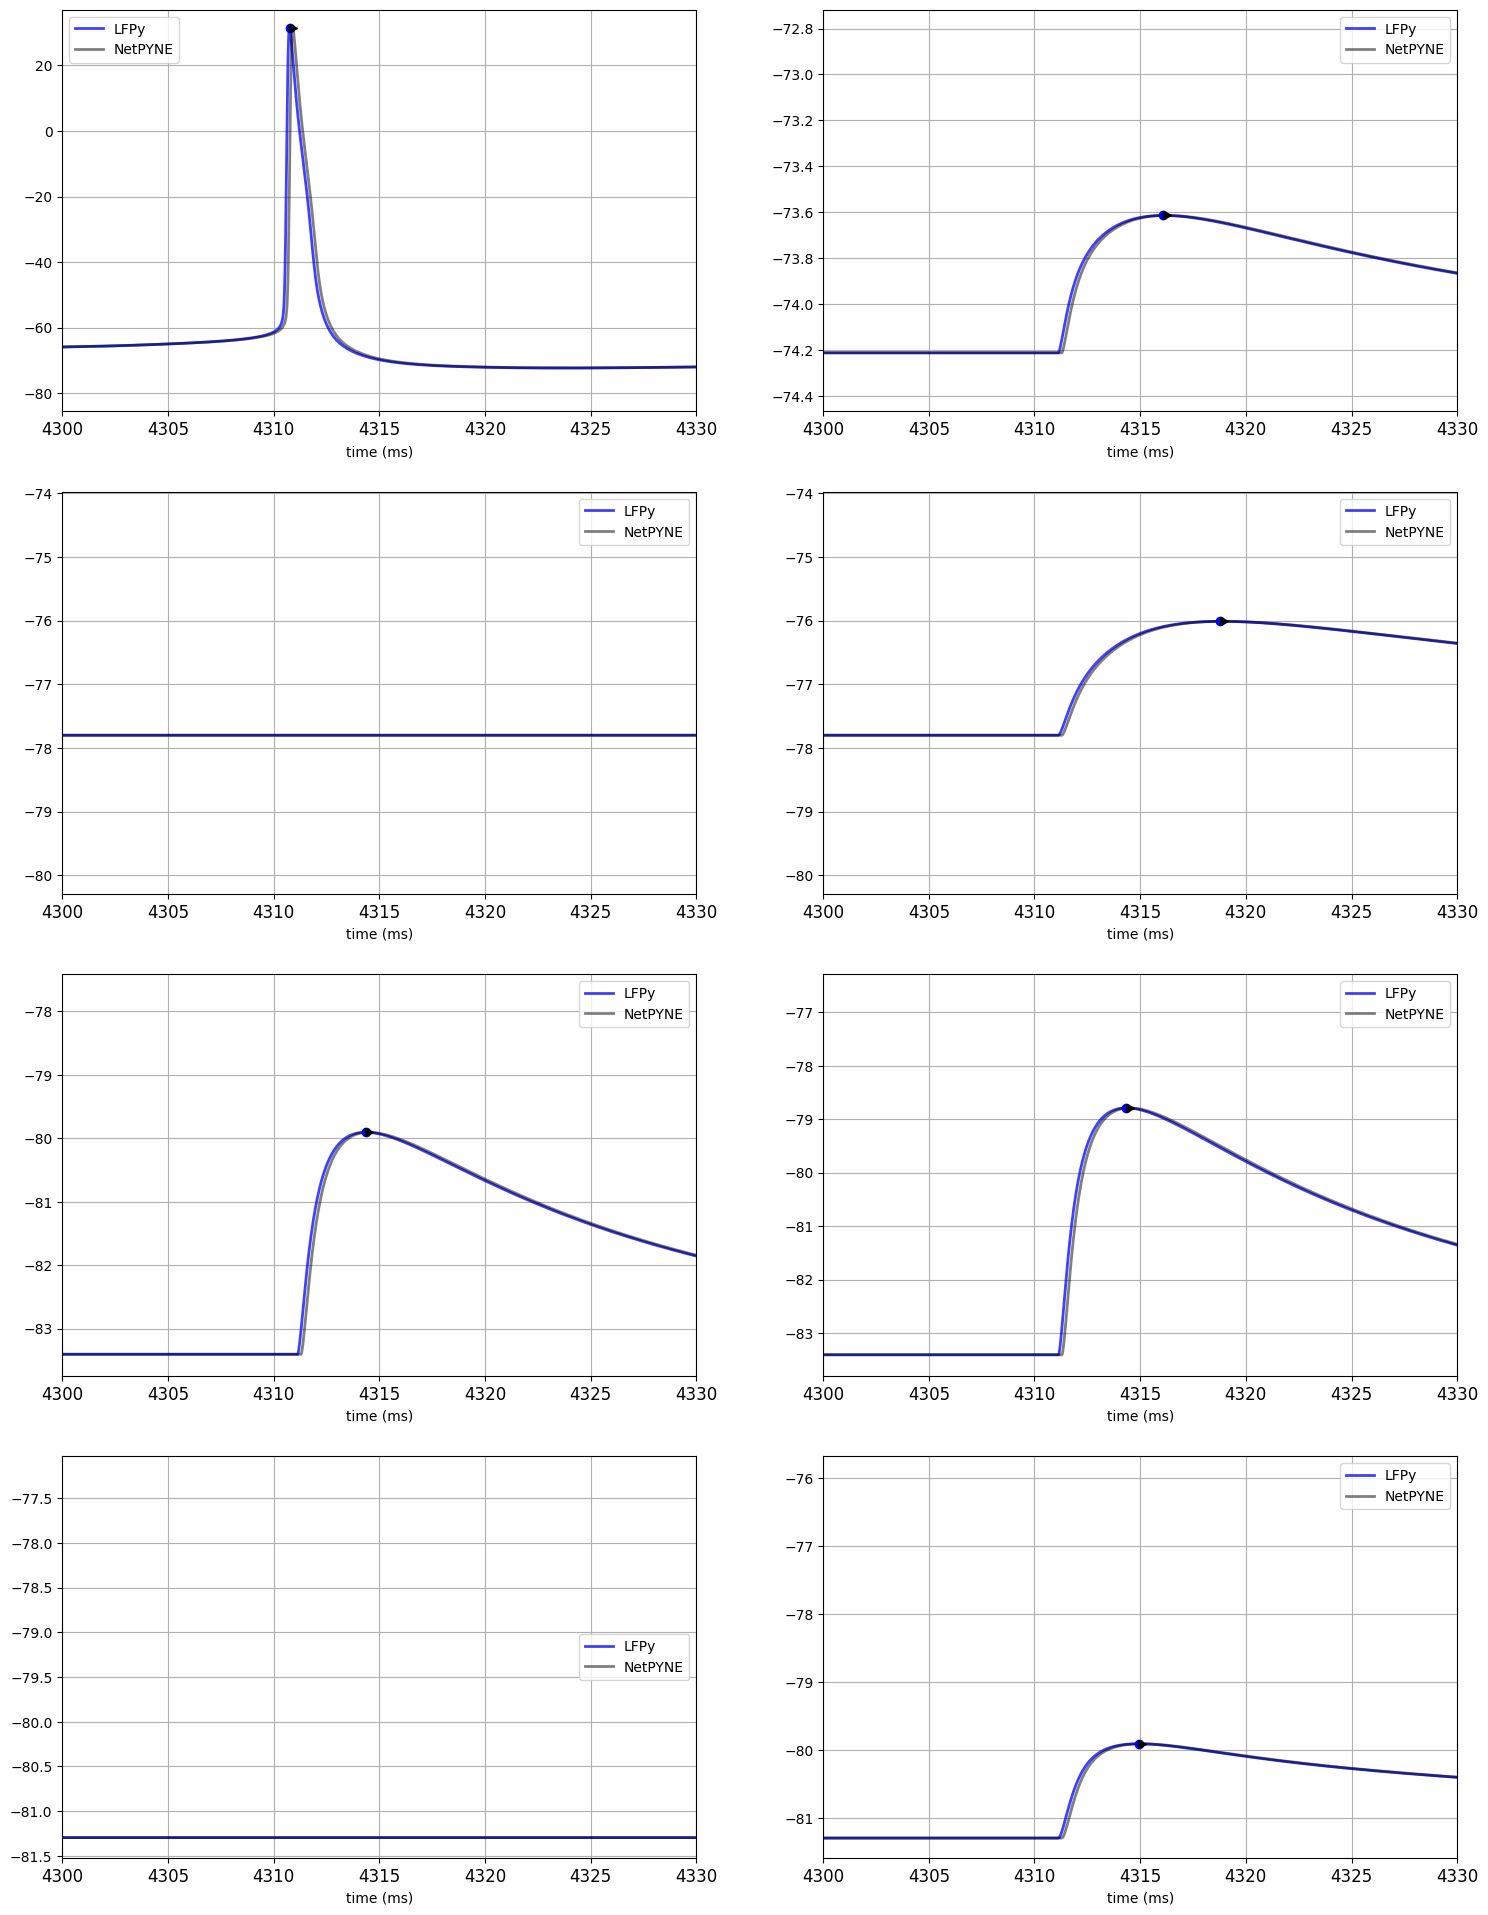

In [30]:
fig = plt.figure(figsize=(18, 24))

N = {}
L = {}
for i in range(4):
    N[i] = []
    L[i] = []

ii = 0
for i in range(4):
    print("\n\n \t POP:", i)
    for j in range(2):
        plt.subplot(4,2, ii+1)
        trace1 = np.asarray(voltage_data[i][j])[4000:10*40000]
        trace2 = data['simData']['V_soma'][cells[ii]][4000:10*40000]
        minV1 = np.min(list(trace1)+list(trace2))
        meanV1 = np.mean(list(trace1)+list(trace2))

        NetPyNEidx, NetPyNEpeak = ss.find_peaks(trace2, height=minV1+0.1)
        LFPyidx, LFPypeak = ss.find_peaks(trace1, height=minV1+0.1)
        
        plt.plot(t[: len(np.asarray(voltage_data[0][0]))], np.asarray(voltage_data[i][j]), label="LFPy", alpha = 0.75, linewidth=2, color='blue')
        plt.plot(data['simData']['t'], data['simData']['V_soma'][cells[ii]], label="NetPYNE", color='k', alpha = 0.5, linewidth=2)
        plt.plot(0.025*LFPyidx+100, LFPypeak['peak_heights'], 'o', color='blue')
        plt.plot(0.025*NetPyNEidx+100, NetPyNEpeak['peak_heights'], '>', color='k')
        if i == 0:
            if j ==1:
                plt.ylim(minV1-0.25, minV1+1.5)
            print("mean PSPs: Exc-Exc -> LFPy: %.6f mV (%d) \t \t NetPyNE: %.6f mV (%d)" % (LFPypeak['peak_heights'].mean()-minV1, len(LFPypeak['peak_heights']), NetPyNEpeak['peak_heights'].mean()-minV1,len(NetPyNEpeak['peak_heights'])))
        else:
            print("mean PSPs: Exc-INH -> LFPy: %.6f mV (%d) \t \t NetPyNE: %.6f mV (%d)" % (LFPypeak['peak_heights'].mean()-minV1, len(LFPypeak['peak_heights']), NetPyNEpeak['peak_heights'].mean()-minV1,len(NetPyNEpeak['peak_heights'])))
        # if i > 0:
            # plt.ylim(minV1-0.5, minV1+4.0)

        plt.xlim(455, 465.0)
        plt.xlim(4300, 4330.0)
        plt.legend()
        plt.grid()

        if i < 30:
            plt.xticks(fontsize=12)
            plt.xlabel("time (ms)")
        else:
            plt.xticks([],fontsize=12)
            plt.xlabel("")
        
        L[i] = L[i] + list(LFPypeak['peak_heights']-minV1)
        N[i] = N[i] + list(NetPyNEpeak['peak_heights']-minV1)
        ii = ii + 1
        if ii ==2:
            print("\n\n",NetPyNEpeak['peak_heights'] - LFPypeak['peak_heights'], "\n\n\n\n")
